In [149]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [150]:
df=pd.read_csv('train.csv')
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [151]:
df=df.drop(columns=['Id'])

In [152]:
df

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [153]:
df.shape

(1460, 80)

In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [155]:
df.isnull().sum()

MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
Street             0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 80, dtype: int64

In [156]:
cols=[]
for features in df.columns:
    if df[features].isnull().sum()>0:
        cols.append(features)

In [157]:
cols

['LotFrontage',
 'Alley',
 'MasVnrType',
 'MasVnrArea',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Electrical',
 'FireplaceQu',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PoolQC',
 'Fence',
 'MiscFeature']

In [158]:
for i in cols:
    print(f"{i} : {df[i].dtype}")

LotFrontage : float64
Alley : object
MasVnrType : object
MasVnrArea : float64
BsmtQual : object
BsmtCond : object
BsmtExposure : object
BsmtFinType1 : object
BsmtFinType2 : object
Electrical : object
FireplaceQu : object
GarageType : object
GarageYrBlt : float64
GarageFinish : object
GarageQual : object
GarageCond : object
PoolQC : object
Fence : object
MiscFeature : object


In [159]:
df.dtypes.value_counts()

object     43
int64      34
float64     3
Name: count, dtype: int64

In [160]:
df.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [161]:
df.describe().T.head(10) # .T means Transpose

,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.0,56.897260,42.300571,20.0,20.0,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.0,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.5,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.0,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.0,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.0,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.0,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.0,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.0,383.5,712.25,5644.0
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.0,0.0,0.00,1474.0


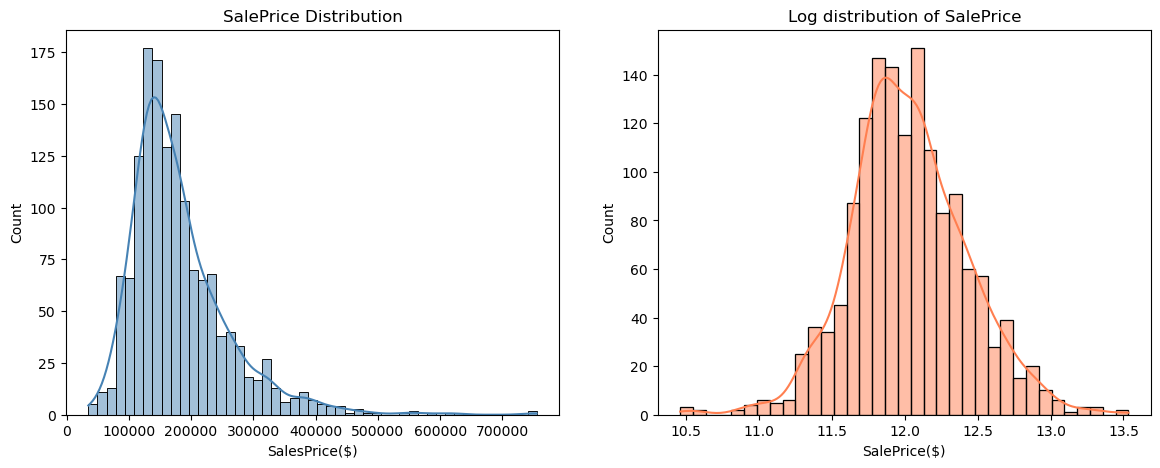

Mean SalePrice 180921.19589041095
Median SalePrice 163000.0


In [162]:
fig, axes=plt.subplots(1,2,figsize=(14,5))
sns.histplot(df['SalePrice'],kde=True,ax=axes[0],color='steelblue')
axes[0].set_title("SalePrice Distribution")
axes[0].set_xlabel("SalesPrice($)")

sns.histplot(np.log1p(df['SalePrice']),kde=True,ax=axes[1],color='coral')
axes[1].set_title("Log distribution of SalePrice")
axes[1].set_xlabel("SalePrice($)")

plt.show()
print(f"Mean SalePrice {df['SalePrice'].mean()}")
print(f"Median SalePrice {df['SalePrice'].median()}")

In [163]:
object_null_cols=[]
for i in cols:
    if df[i].dtype=='O':
        print(i)
        object_null_cols.append(i)
len(object_null_cols)

Alley
MasVnrType
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinType2
Electrical
FireplaceQu
GarageType
GarageFinish
GarageQual
GarageCond
PoolQC
Fence
MiscFeature


16

In [164]:
for i in object_null_cols:
    df[i]=df[i].fillna('None')

In [165]:
df.isnull().sum()

MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
Street             0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 80, dtype: int64

In [166]:
numeric_cols=df.select_dtypes(include=[np.number]).columns
for cols in numeric_cols:
    if df[cols].isnull().any():
        df[cols]=df[cols].fillna(df[cols].median())

In [167]:
print('Missing values after imputation:', df.isnull().sum().sum())

Missing values after imputation: 0


In [168]:
df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.472614
Fireplaces       0.466929
GarageYrBlt      0.466754
BsmtFinSF1       0.386420
LotFrontage      0.334771
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64

In [169]:
df[['GrLivArea','SalePrice']].corr()

,GrLivArea,SalePrice
GrLivArea,1.000000,0.708624
SalePrice,0.708624,1.000000


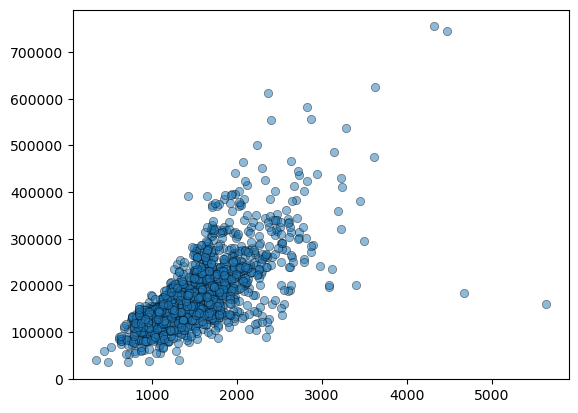

In [170]:
# sns.scatterplot(data=df, x='GrLivArea',y='SalePrice',alpha=0.5, edgecolors='k', linewidth=0.3)
plt.scatter(df['GrLivArea'],df['SalePrice'],alpha=0.5,edgecolors='k',linewidths=0.5)

In [171]:
outliers=(df['GrLivArea']>4000) & (df['SalePrice']<300000)
print(outliers.sum())

2


In [172]:
df=df.loc[~outliers].reset_index(drop=True)
print(df.shape)

(1458, 80)


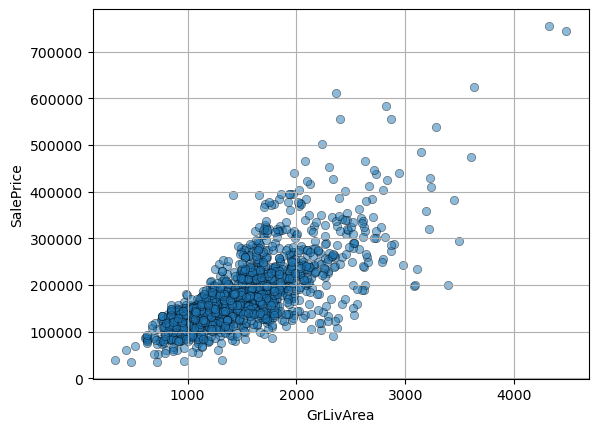

In [173]:
plt.scatter(df['GrLivArea'],df['SalePrice'],alpha=0.5,edgecolors='k',linewidths=0.5)
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.grid()
plt.show()

In [174]:
# TotalSF: overall interior square footage is a strong price driver
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

# HouseAge: newer or recently remodeled homes tend to command higher prices
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']

df[['TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'TotalSF', 'HouseAge', 'RemodAge']].head()

,TotalBsmtSF,1stFlrSF,2ndFlrSF,TotalSF,HouseAge,RemodAge
0,856,856,854,2566,5,5
1,1262,1262,0,2524,31,31
2,920,920,866,2706,7,6
3,756,961,756,2473,91,36
4,1145,1145,1053,3343,8,8


In [175]:
from sklearn.preprocessing import LabelEncoder
# Ordinal mappings preserve natural order (e.g., Po < Fa < TA < Gd < Ex)
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
quality_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
    'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC'
]

for col in quality_cols:
    if col in df.columns:
        df[col] = df[col].map(quality_map).fillna(0).astype(int)

# Additional ordinal features with domain-specific order
ordinal_maps = {
    'BsmtExposure': {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},
    'BsmtFinType1': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'MLQ': 5, 'ALQ': 6, 'GLQ': 7},
    'BsmtFinType2': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'MLQ': 5, 'ALQ': 6, 'GLQ': 7},
    'Functional': {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4, 'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8},
    'GarageFinish': {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3},
    'LandSlope': {'Sev': 1, 'Mod': 2, 'Gtl': 3},
    'LotShape': {'IR3': 1, 'IR2': 2, 'IR1': 3, 'Reg': 4},
    'PavedDrive': {'N': 0, 'P': 1, 'Y': 2},
    'Street': {'Grvl': 1, 'Pave': 2},
    'Utilities': {'ELO': 1, 'NoSeWa': 2, 'NoSewr': 3, 'AllPub': 4},
    'CentralAir': {'N': 0, 'Y': 1},
    'LandContour': {'Low': 1, 'Bnk': 2, 'HLS': 3, 'Lvl': 4},
}

for col, mapping in ordinal_maps.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)
        # Fallback label encoding for any unmapped categories
        if df[col].isnull().any():
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))

# Remaining object columns are nominal → one-hot encode with drop_first to avoid dummy trap
nominal_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Nominal columns to one-hot encode: {len(nominal_cols)}')

df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
print(f'Shape after encoding: {df.shape}')

Nominal columns to one-hot encode: 21
Shape after encoding: (1458, 207)


In [176]:
X=df.drop(columns=['SalePrice'])
y=df['SalePrice']

In [177]:
correlation=X.corrwith(y).sort_values(key=abs,ascending=False)

In [178]:
correlation

TotalSF              0.832877
OverallQual          0.795774
GrLivArea            0.734968
ExterQual            0.686756
KitchenQual          0.662236
                       ...   
Condition2_RRAe      0.002989
Foundation_Wood      0.002705
RoofStyle_Mansard   -0.000319
RoofMatl_Metal      -0.000308
BsmtFinType2        -0.000025
Length: 206, dtype: float64

In [179]:
top_features = correlation.head(20).index.tolist()

In [180]:
top_features

['TotalSF',
 'OverallQual',
 'GrLivArea',
 'ExterQual',
 'KitchenQual',
 'TotalBsmtSF',
 'GarageCars',
 '1stFlrSF',
 'GarageArea',
 'BsmtQual',
 'FullBath',
 'GarageFinish',
 'TotRmsAbvGrd',
 'HouseAge',
 'YearBuilt',
 'FireplaceQu',
 'RemodAge',
 'YearRemodAdd',
 'Foundation_PConc',
 'MasVnrArea']

<Axes: >

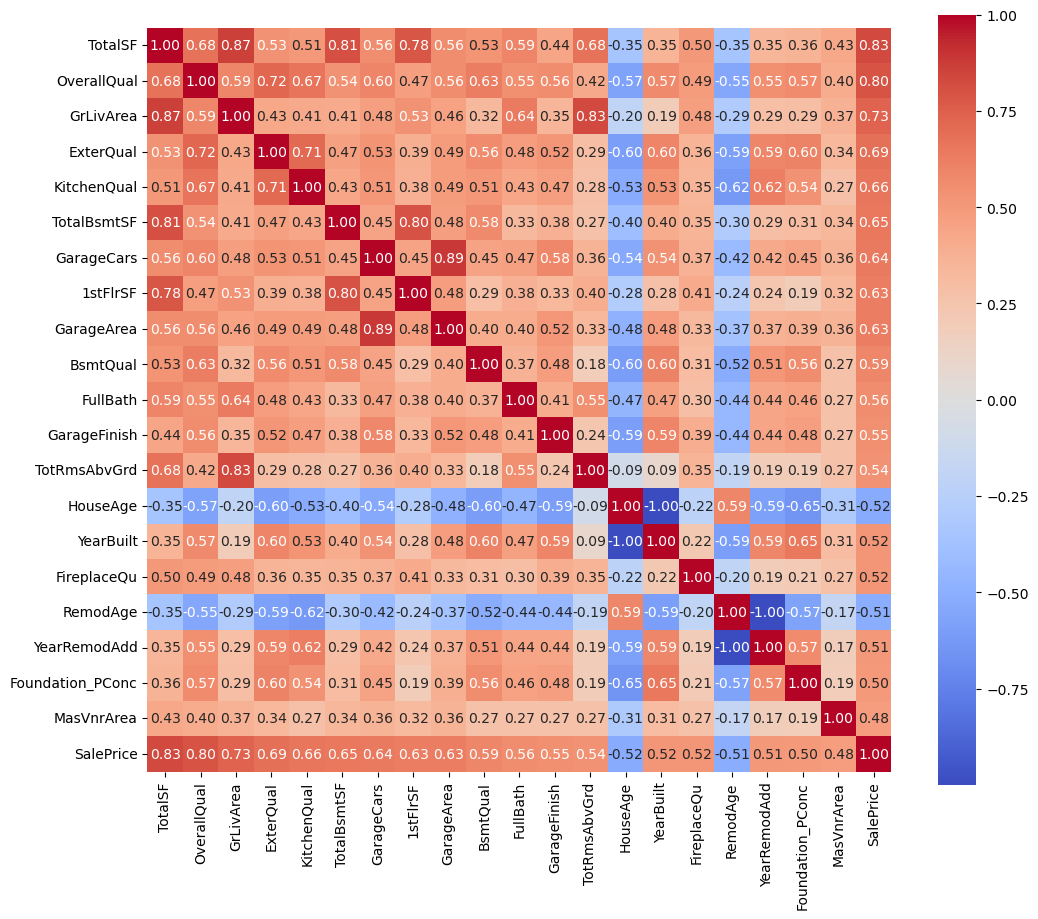

In [181]:
corr_matrix=df[top_features+['SalePrice']].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix,annot=True,fmt='.2f',cmap='coolwarm',square=True)

In [182]:
low_thres=0.05
low_thre_features=correlation[correlation.abs()<low_thres].index.tolist()
low_thre_features

['Condition2_Feedr',
 'Electrical_FuseP',
 'Condition2_PosA',
 'Exterior2nd_Brk Cmn',
 'Condition1_RRAe',
 'SaleCondition_Family',
 'MoSold',
 'Exterior2nd_Other',
 'RoofMatl_WdShake',
 '3SsnPorch',
 'Condition1_PosA',
 'Exterior2nd_Stucco',
 'SaleType_ConLD',
 'SaleType_Con',
 'Street',
 'MiscFeature_Othr',
 'Exterior2nd_Wd Shng',
 'Condition2_RRNn',
 'HouseStyle_SLvl',
 'Neighborhood_NPkVill',
 'Electrical_Mix',
 'HouseStyle_2.5Fin',
 'Exterior1st_Stone',
 'Neighborhood_Gilbert',
 'RoofStyle_Gambrel',
 'SaleType_Oth',
 'Exterior1st_BrkFace',
 'Condition2_Norm',
 'GarageType_Basment',
 'Exterior1st_Stucco',
 'YrSold',
 'Alley_Pave',
 'SaleType_ConLw',
 'Exterior1st_ImStucc',
 'Exterior1st_AsphShn',
 'HouseStyle_2.5Unf',
 'Heating_OthW',
 'LowQualFinSF',
 'Exterior1st_CBlock',
 'Exterior2nd_CBlock',
 'Exterior2nd_BrkFace',
 'Exterior2nd_AsphShn',
 'Neighborhood_NWAmes',
 'Condition1_RRNn',
 'MiscFeature_TenC',
 'MiscVal',
 'RoofStyle_Shed',
 'Neighborhood_Blueste',
 'Heating_GasW',
 'R

In [183]:
X=X.drop(columns=low_thre_features)
print(f'Dropped {len(low_thre_features)} low-correlation features (|r| < {low_thres})')

Dropped 76 low-correlation features (|r| < 0.05)


In [184]:
corr_features=X.corr().abs()
corr_features

,MSSubClass,LotFrontage,LotArea,LotShape,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,...,Fence_MnPrv,Fence_MnWw,Fence_None,MiscFeature_None,MiscFeature_Shed,SaleType_New,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Normal,SaleCondition_Partial
MSSubClass,1.000000,0.374402,0.142033,0.116473,0.025650,0.032522,0.059275,0.027757,0.040503,0.023423,...,0.076197,0.031998,0.103839,0.041817,0.054212,0.045835,0.026737,0.016246,0.024652,0.051778
LotFrontage,0.374402,1.000000,0.274299,0.164396,0.070958,0.219256,0.050705,0.110368,0.076284,0.150829,...,0.010209,0.001211,0.036434,0.008735,0.009204,0.103136,0.071199,0.037790,0.056689,0.101754
LotArea,0.142033,0.274299,1.000000,0.303146,0.443900,0.091392,0.002723,0.007462,0.007500,0.083715,...,0.044251,0.010696,0.044362,0.111227,0.111228,0.001181,0.012534,0.013078,0.018195,0.004084
LotShape,0.116473,0.164396,0.303146,1.000000,0.146149,0.190817,0.032042,0.226674,0.172670,0.076833,...,0.056425,0.020098,0.075457,0.013025,0.007267,0.035713,0.012117,0.014152,0.007960,0.034383
LandSlope,0.025650,0.070958,0.443900,0.146149,1.000000,0.065939,0.010197,0.073343,0.058810,0.020120,...,0.014406,0.008991,0.041145,0.047706,0.054290,0.058614,0.072987,0.011847,0.005008,0.041770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SaleType_New,0.045835,0.103136,0.001181,0.035713,0.058614,0.318733,0.155024,0.344441,0.323273,0.151289,...,0.104034,0.026111,0.146328,0.058732,0.055848,1.000000,0.771319,0.015708,0.642842,0.986622
SaleType_WD,0.026737,0.071199,0.012534,0.012117,0.072987,0.217261,0.162630,0.235540,0.179758,0.116687,...,0.062741,0.010360,0.091793,0.022325,0.016007,0.771319,1.000000,0.020365,0.631632,0.767150
SaleCondition_AdjLand,0.016246,0.037790,0.013078,0.014152,0.011847,0.041703,0.038932,0.045560,0.040248,0.011627,...,0.018220,0.004573,0.025628,0.010286,0.009781,0.015708,0.020365,1.000000,0.112587,0.015921
SaleCondition_Normal,0.024652,0.056689,0.018195,0.007960,0.005008,0.136177,0.160659,0.155549,0.117760,0.071478,...,0.034666,0.000795,0.045924,0.053412,0.047107,0.642842,0.631632,0.112587,1.000000,0.651559


In [185]:
upper_triangle=corr_features.where(np.triu(np.ones(corr_features.shape),k=1).astype(bool))
upper_triangle

,MSSubClass,LotFrontage,LotArea,LotShape,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,...,Fence_MnPrv,Fence_MnWw,Fence_None,MiscFeature_None,MiscFeature_Shed,SaleType_New,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Normal,SaleCondition_Partial
MSSubClass,NaN,0.374402,0.142033,0.116473,0.025650,0.032522,0.059275,0.027757,0.040503,0.023423,...,0.076197,0.031998,0.103839,0.041817,0.054212,0.045835,0.026737,0.016246,0.024652,0.051778
LotFrontage,NaN,NaN,0.274299,0.164396,0.070958,0.219256,0.050705,0.110368,0.076284,0.150829,...,0.010209,0.001211,0.036434,0.008735,0.009204,0.103136,0.071199,0.037790,0.056689,0.101754
LotArea,NaN,NaN,NaN,0.303146,0.443900,0.091392,0.002723,0.007462,0.007500,0.083715,...,0.044251,0.010696,0.044362,0.111227,0.111228,0.001181,0.012534,0.013078,0.018195,0.004084
LotShape,NaN,NaN,NaN,NaN,0.146149,0.190817,0.032042,0.226674,0.172670,0.076833,...,0.056425,0.020098,0.075457,0.013025,0.007267,0.035713,0.012117,0.014152,0.007960,0.034383
LandSlope,NaN,NaN,NaN,NaN,NaN,0.065939,0.010197,0.073343,0.058810,0.020120,...,0.014406,0.008991,0.041145,0.047706,0.054290,0.058614,0.072987,0.011847,0.005008,0.041770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SaleType_New,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.771319,0.015708,0.642842,0.986622
SaleType_WD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.020365,0.631632,0.767150
SaleCondition_AdjLand,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.112587,0.015921
SaleCondition_Normal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.651559


In [186]:
multicollinear_cols=[
    cols for cols in upper_triangle.columns
    if any(upper_triangle[cols]>0.90)
]
multicollinear_cols

['GarageCond',
 'PoolQC',
 'HouseAge',
 'RemodAge',
 'RoofStyle_Hip',
 'Exterior2nd_CmentBd',
 'Exterior2nd_MetalSd',
 'Exterior2nd_VinylSd',
 'GarageType_None',
 'MiscFeature_Shed',
 'SaleCondition_Partial']

In [187]:
preferred_drops = ['TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GarageCars', 'TotRmsAbvGrd']
cols_to_drop = [col for col in preferred_drops if col in multicollinear_cols]
cols_to_drop += [col for col in multicollinear_cols if col not in cols_to_drop]

In [188]:
X = X.drop(columns=cols_to_drop, errors='ignore')
print(f'Dropped {len(cols_to_drop)} multicollinear features: {cols_to_drop}')
print(f'Final feature count: {X.shape[1]}')

Dropped 11 multicollinear features: ['GarageCond', 'PoolQC', 'HouseAge', 'RemodAge', 'RoofStyle_Hip', 'Exterior2nd_CmentBd', 'Exterior2nd_MetalSd', 'Exterior2nd_VinylSd', 'GarageType_None', 'MiscFeature_Shed', 'SaleCondition_Partial']
Final feature count: 119


In [190]:
from sklearn.model_selection import train_test_split
X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=0.20,random_state=42)

In [191]:
X_train.shape

(1166, 119)

In [192]:
X_val.shape

(292, 119)

In [193]:
from sklearn.linear_model import LinearRegression
lr_model=LinearRegression()
lr_model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [194]:
from sklearn.linear_model import Ridge
ridge_model=Ridge(alpha=1.0,random_state=42)
ridge_model.fit(X_train,y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,42


In [195]:
from sklearn.linear_model import Lasso
lasso_model=Lasso(alpha=0.001, random_state=42,max_iter=10000)
lasso_model.fit(X_train,y_train)

,alpha,0.001
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,10000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


In [202]:
from sklearn.metrics import mean_squared_error
def rmse(y_true,y_pred):
    return np.sqrt(mean_squared_error(y_true,y_pred))
models={
    "LinearRegression":lr_model,
    "Ridge":ridge_model,
    "Lasso":lasso_model,
}
for name, model in models.items():
    train_score = rmse(y_train, model.predict(X_train))
    val_score = rmse(y_val, model.predict(X_val))
    print(f'{name:22s} | Train RMSE: ${train_score:,.0f} | Val RMSE: ${val_score:,.0f}')

LinearRegression       | Train RMSE: $22,548 | Val RMSE: $26,068
Ridge                  | Train RMSE: $22,644 | Val RMSE: $25,257
Lasso                  | Train RMSE: $22,548 | Val RMSE: $26,068


In [203]:
from sklearn.model_selection import cross_val_score
# 5-fold CV on training data — negative MSE because sklearn maximizes scores
cv_folds = 5
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv_folds,
        scoring='neg_root_mean_squared_error'
    )
    cv_results[name] = -scores
    print(f'{name:22s} | CV RMSE: ${cv_results[name].mean():,.0f} ± ${cv_results[name].std():,.0f}')

LinearRegression       | CV RMSE: $27,716 ± $1,809
Ridge                  | CV RMSE: $27,382 ± $1,345
Lasso                  | CV RMSE: $27,716 ± $1,809


In [204]:
from sklearn.model_selection import GridSearchCV
# GridSearchCV to find optimal alpha for Ridge and Lasso
alpha_grid = np.logspace(-2, 3, 50)
print(alpha_grid)
param_grid = {'alpha': alpha_grid}

ridge_search = GridSearchCV(
    Ridge(random_state=42),
    param_grid,
    cv=cv_folds,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
ridge_search.fit(X_train, y_train)

lasso_search = GridSearchCV(
    Lasso(random_state=42, max_iter=10000),
    param_grid,
    cv=cv_folds,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
lasso_search.fit(X_train, y_train)

print(f'Best Ridge alpha: {ridge_search.best_params_["alpha"]:.4f}')
print(f'Best Lasso alpha: {lasso_search.best_params_["alpha"]:.4f}')

# Retrain tuned models on full training set
best_ridge = ridge_search.best_estimator_
best_lasso = lasso_search.best_estimator_

tuned_models = {
    'Linear Regression': lr_model,
    'Ridge Regression': best_ridge,
    'Lasso Regression': best_lasso,
}

[1.00000000e-02 1.26485522e-02 1.59985872e-02 2.02358965e-02
 2.55954792e-02 3.23745754e-02 4.09491506e-02 5.17947468e-02
 6.55128557e-02 8.28642773e-02 1.04811313e-01 1.32571137e-01
 1.67683294e-01 2.12095089e-01 2.68269580e-01 3.39322177e-01
 4.29193426e-01 5.42867544e-01 6.86648845e-01 8.68511374e-01
 1.09854114e+00 1.38949549e+00 1.75751062e+00 2.22299648e+00
 2.81176870e+00 3.55648031e+00 4.49843267e+00 5.68986603e+00
 7.19685673e+00 9.10298178e+00 1.15139540e+01 1.45634848e+01
 1.84206997e+01 2.32995181e+01 2.94705170e+01 3.72759372e+01
 4.71486636e+01 5.96362332e+01 7.54312006e+01 9.54095476e+01
 1.20679264e+02 1.52641797e+02 1.93069773e+02 2.44205309e+02
 3.08884360e+02 3.90693994e+02 4.94171336e+02 6.25055193e+02
 7.90604321e+02 1.00000000e+03]
Best Ridge alpha: 4.4984
Best Lasso alpha: 75.4312
